In [7]:
import scanpy as sc
import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import gzip

sc.settings.set_figure_params(dpi=80)

In [8]:
# 输入目录
input_dir = '/project-whj/sis/2.tumbler/10.SC/1.expression_matrix/WMS509-XN/outs/filtered_cell_gene_matrix'
matrix_file = input_dir + '/matrix.mtx.gz'
features_file = input_dir + '/features.tsv.gz'
barcodes_file = input_dir + '/barcodes.tsv.gz'
out_dir = '/project-whj/sis/2.tumbler/10.SC/3.Seurat+scrublet'

# 读取压缩的矩阵文件
counts_matrix = scipy.io.mmread(matrix_file).T.tocsc()

# 读取 features.tsv.gz 文件
features_df = pd.read_csv(features_file, compression='gzip', delimiter='\t', header=None)
genes = np.array(features_df.iloc[:, 1].values)  # 提取第二列（基因名称）

# 读取 barcodes.tsv.gz 文件
barcodes_df = pd.read_csv(barcodes_file, compression='gzip', header=None, names=['barcode'])
barcodes = np.array(barcodes_df['barcode'].values)

# 打印矩阵形状
print('Counts matrix shape: {} rows, {} columns'.format(counts_matrix.shape[0], counts_matrix.shape[1]))

# 打印基因信息
print('Genes:', genes)

# 打印细胞条形码信息
print('Barcodes:', barcodes)

Counts matrix shape: 14204 rows, 22583 columns
Genes: ['LOC135579015' 'FHIP1B' 'CNGA4' ... 'KEH11_t21' 'ND6' 'KEH11_t22']
Barcodes: ['AACAACACGAAGTACCAGCG' 'AACAACACGACAACATCCTG' 'AACAACACGACCGTGCCGCA' ...
 'TTGTTCTTGGGTCTATCACC' 'TTGTTCTTGGTACAGGATTA' 'TTGTTCTTGGTGCCAAGATT']


In [9]:

scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.06)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.71
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 1.4%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 3.1%
Elapsed time: 37.6 seconds
Detected doublet rate = 2.1%
Estimated detectable doublet fraction = 24.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 8.8%


/project-whj/sis/software/anaconda3/envs/seurat_v5/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(<Figure size 640x320 with 3 Axes>,
 array([<Axes: title={'center': 'Predicted doublets'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
        <Axes: title={'center': 'Doublet score'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
       dtype=object))

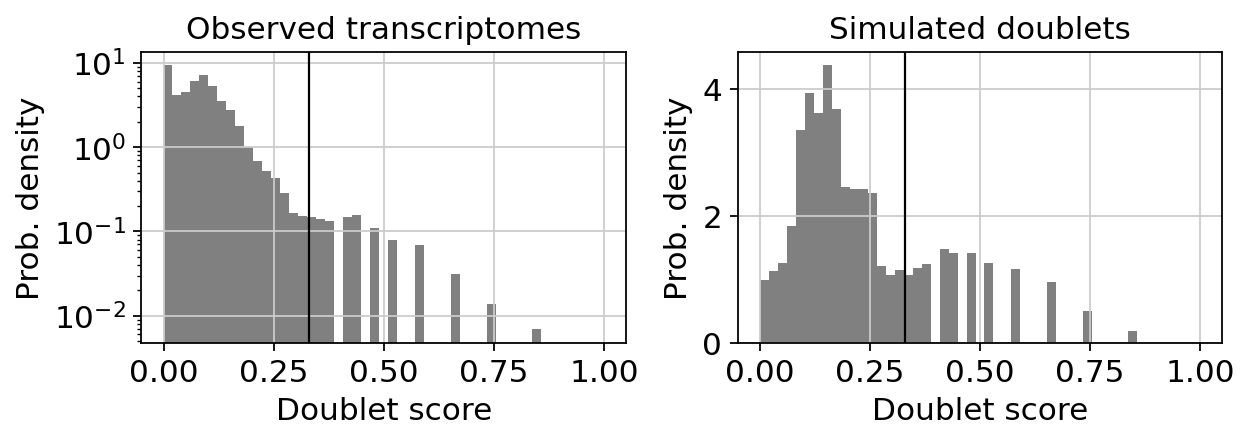

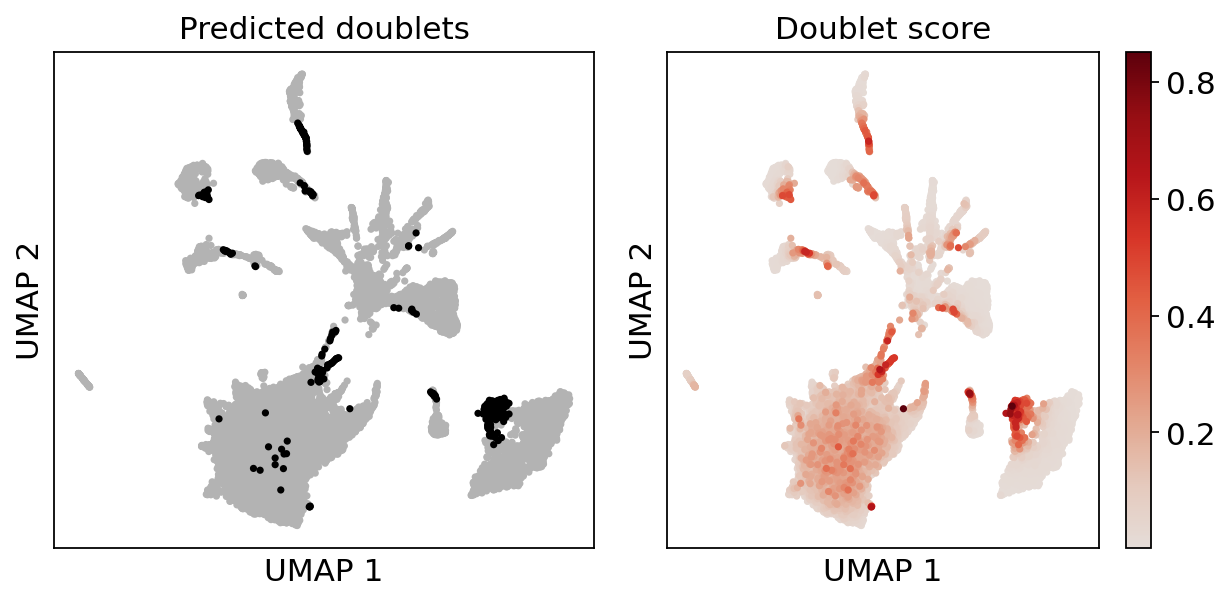

In [10]:
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30)
predicted_doublets = scrub.call_doublets(threshold=0.33)
scrub.plot_histogram()
#predicted_doublets = scrub.call_doublets(threshold=0.33)
#scrub.plot_histogram()
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)
# scrub.plot_embedding('tSNE', order_points=True);
# scrub.plot_embedding('FA', order_points=True);

In [11]:
# doublets占比
print (scrub.detected_doublet_rate_)

0.021191213742607715


In [12]:
barcodes_df['doublet_scores'] = doublet_scores
barcodes_df['predicted_doublets'] = predicted_doublets
barcodes_df.to_csv(out_dir + '/WMS509-XN-doublet.txt', index=False,header=True)
barcodes_df.head()

,barcode,doublet_scores,predicted_doublets
0,AACAACACGAAGTACCAGCG,0.023894,False
1,AACAACACGACAACATCCTG,0.046492,False
2,AACAACACGACCGTGCCGCA,0.077708,False
3,AACAACACGACGGCACCTTC,0.058177,False
4,AACAACACGAGAATTCACAA,0.111168,False
